# 10-Year 105,120 5-Minute Interval HMM Transition Analysis & Dataset Generation (v2 — mean-Only Feature)

## Objectives
1. **Load 10-Year 5-Minute Rainfall Data (4-Gauge Average)**: Aggregate 5-minute spatial average rainfall records across all 4 rain gauges in Astlingen (2000–2009) into a 10-year 5-minute dataset (1,051,200 records).
2. **Construct 1-Year (105,120 5-Minute Interval) Climatological mean Profile**: Rather than extracting multiple multi-metric daily features (sum, max, zero fraction), compute the 10-year **mean** rainfall intensity directly per 5-minute annual interval position (365 days × 288 intervals/day = 105,120 slots) to obtain a robust 1D climatological rainfall profile. Apply a 14-day rolling window (4,032 5-minute steps) for climatological smoothing.
3. **Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D mean Profile**: Train a 4-state GaussianHMM directly on the standardized 105,120 1D climatological mean profile.
4. **Reorder & Characterize HMM States**: Sort state indices (0 to 3) by mean mean rainfall intensity (State 0: Dry/Low Activity, State 1: Light/Moderate Rain, State 2: Heavy/Convective Rain, State 3: Peak/Intense Storms).
5. **Observe & Visualize 105,120-Interval Transition Matrix**: Extract the 4x4 state transition matrix, compute transition dynamics, and render a high-quality heatmap visualization.
6. **Visualize 105,120-Interval Climatological Regimes**: Plot the annual 105,120 5-minute rainfall profile colored by hidden state transitions across the 365-day year.
7. **Broadcast 105,120 HMM State Sequence to Full 5-Minute Dataset**: Map the 105,120 5-minute HMM state sequence back to each 5-minute record in the 10-year dataset (1,051,200 records).
8. **Export New v2 Labeled Dataset**: Save the dataset containing `date`, `time`, `rainfall_intensity`, `day_of_year`, and `hmm_state` to `../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_v2_fit_hmm.csv`.
9. **Visualize Sample 5-Minute Time Series with Broadcasted HMM States**: Render a sample 14-day window of 5-minute rainfall intensity overlaid with background shading for the predicted HMM state regimes.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

## Step 1: Load 10-Year 5-Minute Data & Compute 4-Gauge Average
We load all 4 rain gauge datasets (Astlingen Erft 1–4) for 2000–2009, compute the spatial average 5-minute rainfall intensity, and set up annual interval indexing (0 to 105,119).

In [2]:
# Load all 4 raw 5-minute rainfall gauge datasets
file_paths = sorted(glob.glob('../data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))
if not file_paths:
    file_paths = sorted(glob.glob('data/rainfall/astlingen/[1-4]Astlingen_Erft*.csv'))

print(f"Loading {len(file_paths)} rain gauge datasets:")
for p in file_paths:
    print(f" - {p}")

gauge_dfs = []
for path in file_paths:
    g_df = pd.read_csv(path)
    g_df['datetime'] = pd.to_datetime(g_df['date'] + ' ' + g_df['time'], format='%m/%d/%Y %H:%M:%S')
    g_df.set_index('datetime', inplace=True)
    gauge_dfs.append(g_df['rainfall_intensity'])

# Combine and compute 4-gauge average 5-minute rainfall intensity
df_5min_full = pd.concat(gauge_dfs, axis=1).mean(axis=1).to_frame(name='rainfall_intensity').reset_index()

# Add year, day_of_year, interval_of_day
df_5min_full['year'] = df_5min_full['datetime'].dt.year
df_5min_full['day_of_year'] = df_5min_full['datetime'].dt.dayofyear
df_5min_full['interval_of_day'] = (df_5min_full['datetime'].dt.hour * 12 + df_5min_full['datetime'].dt.minute // 5)

# Calculate annual 5-minute interval index (0 to 105,119)
day_capped = df_5min_full['day_of_year'].clip(upper=365)
df_5min_full['annual_interval_idx'] = (day_capped - 1) * 288 + df_5min_full['interval_of_day']

print(f"Full 10-Year 5-Minute Dataset Shape: {df_5min_full.shape}")
print(df_5min_full.head())

Loading 4 rain gauge datasets:
 - ../data/rainfall/astlingen/1Astlingen_Erft1.csv
 - ../data/rainfall/astlingen/2Astlingen_Erft2.csv
 - ../data/rainfall/astlingen/3Astlingen_Erft3.csv
 - ../data/rainfall/astlingen/4Astlingen_Erft4.csv
Full 10-Year 5-Minute Dataset Shape: (1051200, 6)
             datetime  rainfall_intensity  year  day_of_year  interval_of_day  \
0 2000-01-01 00:00:00               0.005  2000            1                0   
1 2000-01-01 00:05:00               0.000  2000            1                1   
2 2000-01-01 00:10:00               0.000  2000            1                2   
3 2000-01-01 00:15:00               0.000  2000            1                3   
4 2000-01-01 00:20:00               0.000  2000            1                4   

   annual_interval_idx  
0                    0  
1                    1  
2                    2  
3                    3  
4                    4  


## Step 2: Construct 1-Year (105,120 5-Minute Interval) Climatological Median Profile
We aggregate across 10 years by `annual_interval_idx` (0 to 105,119) to compute the **median** rainfall intensity for each 5-minute annual interval slot, then apply a 14-day rolling mean (4,032 5-minute steps) to smooth high-frequency noise into continuous seasonal signals.

In [3]:
# Filter out leap-year day 366 for consistent 365-day annual alignment (365 * 288 = 105,120 intervals)
df_365 = df_5min_full[df_5min_full['day_of_year'] <= 365].copy()

# Compute 10-year median rainfall intensity per annual interval slot
clim_105120 = df_365.groupby('annual_interval_idx').agg(
    median_intensity=('rainfall_intensity', 'median'),
    mean_intensity=('rainfall_intensity', 'mean'),
    day_of_year=('day_of_year', 'first'),
).reset_index().set_index('annual_interval_idx')

# Apply 14-day rolling window (4,032 5-min intervals) to smooth the median profile
clim_105120['median_intensity_smooth'] = clim_105120['median_intensity'].rolling(
    window=4032, min_periods=1, center=True
).mean()

# Also compute smoothed mean for reference comparison
clim_105120['mean_intensity_smooth'] = clim_105120['mean_intensity'].rolling(
    window=4032, min_periods=1, center=True
).mean()

print(f"105,120-interval climatological median profile shape: {clim_105120.shape}")
print(clim_105120.head())

105,120-interval climatological median profile shape: (105120, 5)
                     median_intensity  mean_intensity  day_of_year  \
annual_interval_idx                                                  
0                                 0.0         0.00050            1   
1                                 0.0         0.00075            1   
2                                 0.0         0.00000            1   
3                                 0.0         0.00225            1   
4                                 0.0         0.00250            1   

                     median_intensity_smooth  mean_intensity_smooth  
annual_interval_idx                                                  
0                                   0.000009               0.008204  
1                                   0.000009               0.008200  
2                                   0.000009               0.008195  
3                                   0.000009               0.008191  
4                      

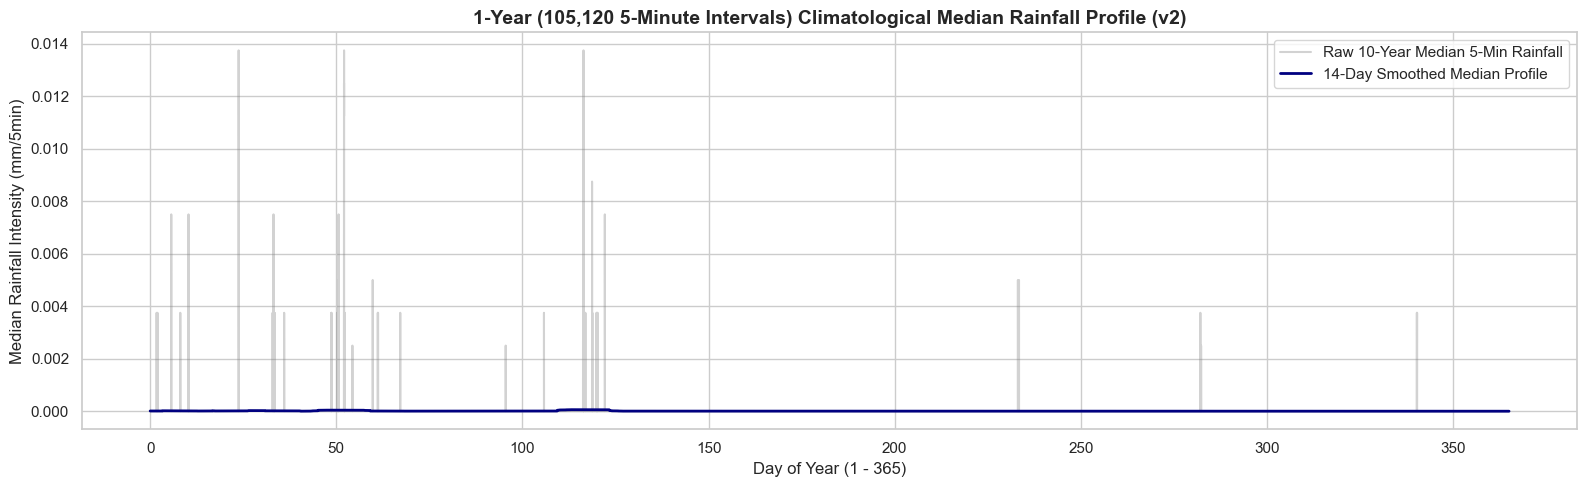

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
days = clim_105120.index / 288.0

ax.plot(days, clim_105120['median_intensity'], alpha=0.35, color='gray', label='Raw 10-Year Median 5-Min Rainfall')
ax.plot(days, clim_105120['median_intensity_smooth'], color='navy', linewidth=2, label='14-Day Smoothed Median Profile')
ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological Median Rainfall Profile (v2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Median Rainfall Intensity (mm/5min)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

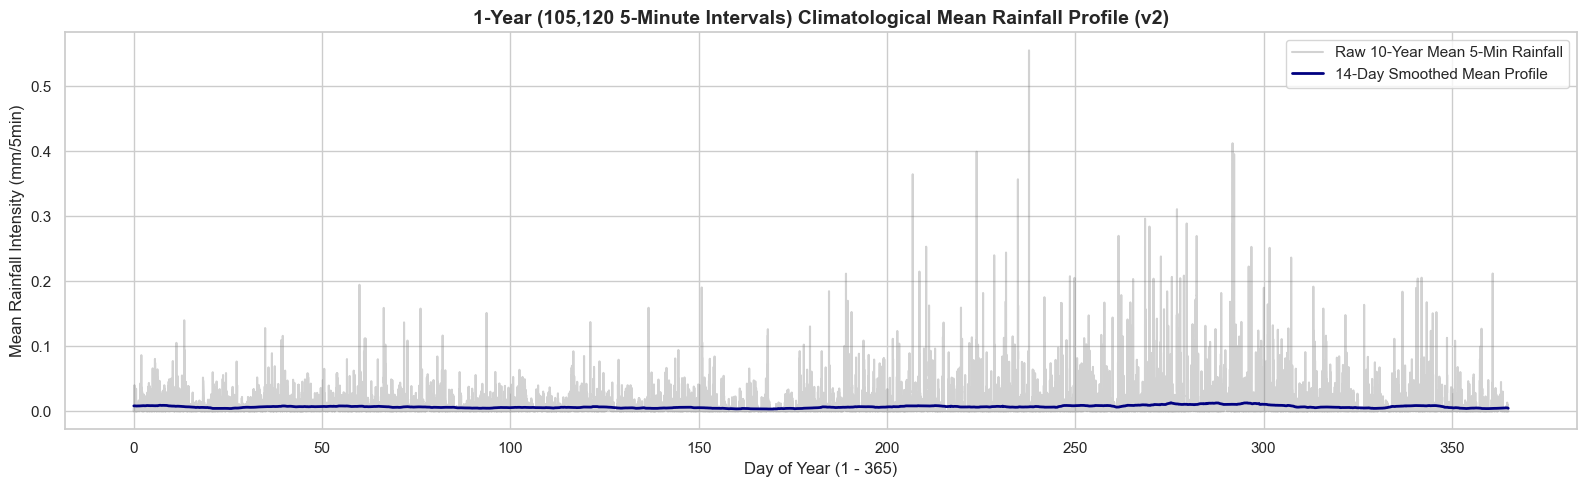

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
days = clim_105120.index / 288.0

ax.plot(days, clim_105120['mean_intensity'], alpha=0.35, color='gray', label='Raw 10-Year Mean 5-Min Rainfall')
ax.plot(days, clim_105120['mean_intensity_smooth'], color='navy', linewidth=2, label='14-Day Smoothed Mean Profile')
ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological Mean Rainfall Profile (v2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Mean Rainfall Intensity (mm/5min)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Step 3: Fit Gaussian Hidden Markov Model (GaussianHMM) Directly on 105,120 1D Median Profile
We standardize the 105,120 1D smoothed median profile and train a 4-state GaussianHMM directly on the 105,120 interval sequence.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clim_105120[['mean_intensity_smooth']])

n_states = 4
hmm_model = hmm.GaussianHMM(n_components=n_states, covariance_type='full', n_iter=200, random_state=42)
hmm_model.fit(X_scaled)

raw_states = hmm_model.predict(X_scaled)
clim_105120['raw_state'] = raw_states

# Reorder states by mean smoothed mean intensity (0: Lowest -> 3: Highest)
state_means = clim_105120.groupby('raw_state')['mean_intensity_smooth'].mean().sort_values()
state_map = {old_st: new_st for new_st, old_st in enumerate(state_means.index)}
clim_105120['hmm_state'] = clim_105120['raw_state'].map(state_map)

# Also reorder the transition matrix
transmat_raw = hmm_model.transmat_
transmat_ordered = np.zeros_like(transmat_raw)
for old_i, new_i in state_map.items():
    for old_j, new_j in state_map.items():
        transmat_ordered[new_i, new_j] = transmat_raw[old_i, old_j]

print("HMM Fitting Complete!")
print("State Map (Raw -> Ordered):", state_map)
print(f"Re-ordered State Means (Mean Intensity mm/5min):")
print(clim_105120.groupby('hmm_state')['mean_intensity'].mean())

HMM Fitting Complete!
State Map (Raw -> Ordered): {2: 0, 0: 1, 3: 2, 1: 3}
Re-ordered State Means (Mean Intensity mm/5min):
hmm_state
0    0.004636
1    0.006055
2    0.007596
3    0.010897
Name: mean_intensity, dtype: float64


## Step 4: Observe & Visualize Transition Matrix
We extract the 4x4 state transition matrix from the 105,120 predicted HMM state sequence and render a high-quality heatmap visualization.

In [7]:
state_names = [
    'State 0 (Dry / Low Activity)',
    'State 1 (Moderate / Light Rain)',
    'State 2 (Heavy / Convective)',
    'State 3 (Peak / Intense Storms)'
]

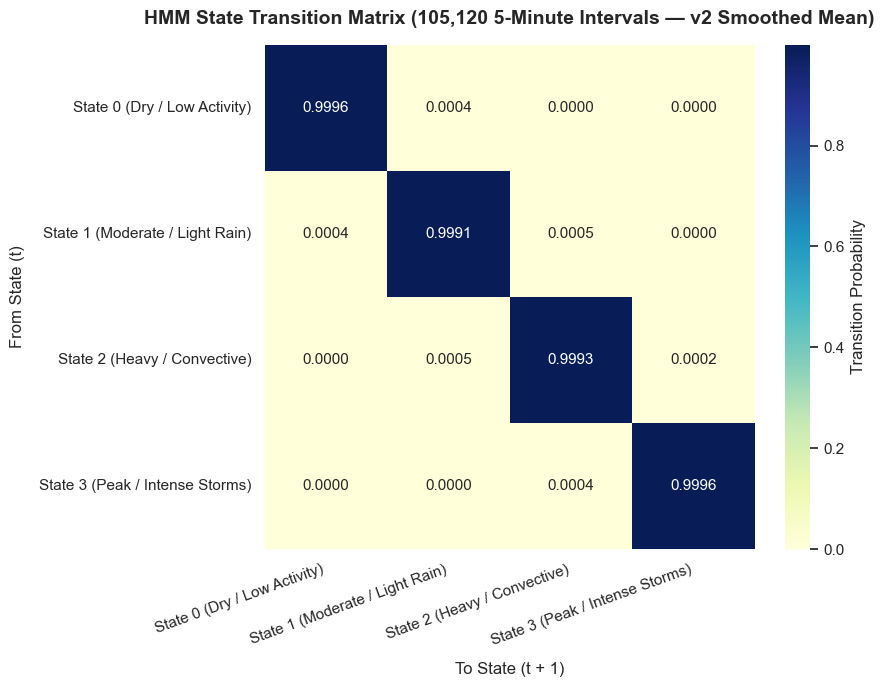

                                 State 0 (Dry / Low Activity)  \
State 0 (Dry / Low Activity)                         0.999581   
State 1 (Moderate / Light Rain)                      0.000410   
State 2 (Heavy / Convective)                         0.000000   
State 3 (Peak / Intense Storms)                      0.000000   

                                 State 1 (Moderate / Light Rain)  \
State 0 (Dry / Low Activity)                            0.000419   
State 1 (Moderate / Light Rain)                         0.999117   
State 2 (Heavy / Convective)                            0.000512   
State 3 (Peak / Intense Storms)                         0.000000   

                                 State 2 (Heavy / Convective)  \
State 0 (Dry / Low Activity)                         0.000000   
State 1 (Moderate / Light Rain)                      0.000473   
State 2 (Heavy / Convective)                         0.999328   
State 3 (Peak / Intense Storms)                      0.000368   

       

In [8]:
# Compute 4x4 empirical transition matrix across 105,120 intervals
trans_matrix = np.zeros((n_states, n_states))
for t in range(len(clim_105120) - 1):
    i = clim_105120['hmm_state'].iloc[t]
    j = clim_105120['hmm_state'].iloc[t+1]
    trans_matrix[i, j] += 1

# Normalize transition matrix rows to probabilities
trans_matrix_prob = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)

# Plot Transition Matrix Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(trans_matrix_prob, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=state_names, yticklabels=state_names,
            cbar_kws={'label': 'Transition Probability'})
plt.title("HMM State Transition Matrix (105,120 5-Minute Intervals — v2 Smoothed Mean)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("To State (t + 1)", fontsize=12, labelpad=10)
plt.ylabel("From State (t)", fontsize=12, labelpad=10)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print Transition Probabilities DataFrame
trans_df = pd.DataFrame(trans_matrix_prob, index=state_names, columns=state_names)
print(trans_df)

## Step 5: Visualize 105,120-Interval Climatological Regimes & State Transitions
We plot the 105,120 5-minute annual rainfall profile colored by hidden state transitions across the 365 days of the year.

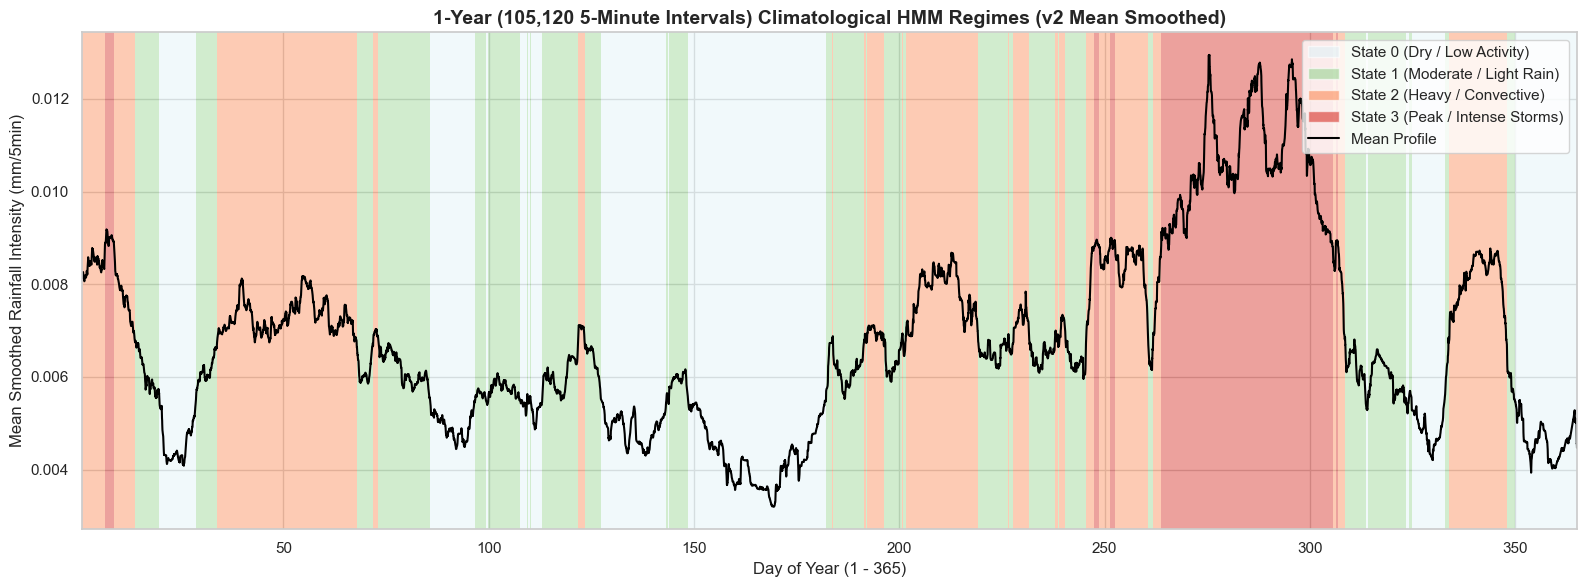

In [9]:
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

fig, ax = plt.subplots(figsize=(16, 6))
days = clim_105120.index / 288.0

# Background shading for HMM states across 105,120 intervals
current_state = clim_105120['hmm_state'].iloc[0]
start_idx = 0

for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state'].iloc[i] != current_state or i == len(clim_105120) - 1:
        ax.axvspan(days[start_idx], days[i], color=colors[current_state], alpha=0.45, linewidth=0)
        current_state = clim_105120['hmm_state'].iloc[i]
        start_idx = i

ax.plot(days, clim_105120['mean_intensity_smooth'], color='black', linewidth=1.5, label='Smoothed Mean Profile')

legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='black', lw=1.5, label='Mean Profile'))

ax.set_title('1-Year (105,120 5-Minute Intervals) Climatological HMM Regimes (v2 Mean Smoothed)', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year (1 - 365)')
ax.set_ylabel('Mean Smoothed Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')
ax.set_xlim(1, 365)

plt.tight_layout()
plt.show()

## Step 6: HMM Regime Characterization Summary
We aggregate statistics (smoothed median intensity, mean intensity, interval count, and percentage of year) for each of the 4 discovered HMM states across the 105,120 intervals.

In [10]:
summary_df = clim_105120.groupby('hmm_state')[['median_intensity_smooth', 'mean_intensity_smooth']].mean()
summary_df.columns = ['Mean Smoothed Median (mm/5min)', 'Mean Intensity (mm/5min)']
summary_df['Interval_Count'] = clim_105120.groupby('hmm_state').size()
summary_df['Pct_of_Year'] = (summary_df['Interval_Count'] / len(clim_105120) * 100).round(2)
summary_df.index = state_names
print(summary_df)

                                 Mean Smoothed Median (mm/5min)  \
State 0 (Dry / Low Activity)                           0.000003   
State 1 (Moderate / Light Rain)                        0.000007   
State 2 (Heavy / Convective)                           0.000010   
State 3 (Peak / Intense Storms)                        0.000001   

                                 Mean Intensity (mm/5min)  Interval_Count  \
State 0 (Dry / Low Activity)                     0.004645           28608   
State 1 (Moderate / Light Rain)                  0.006139           31697   
State 2 (Heavy / Convective)                     0.007693           31228   
State 3 (Peak / Intense Storms)                  0.010476           13587   

                                 Pct_of_Year  
State 0 (Dry / Low Activity)           27.21  
State 1 (Moderate / Light Rain)        30.15  
State 2 (Heavy / Convective)           29.71  
State 3 (Peak / Intense Storms)        12.93  


## Step 7: Broadcast 105,120-Interval HMM State Sequence to Full 5-Minute Dataset
We map the 105,120 5-minute HMM state sequence (`hmm_state` 0–3) back to each 5-minute record in the 10-year dataset (1,051,200 records) based on `annual_interval_idx` and export the v2 datasets.

In [11]:
# Create mapping from annual_interval_idx (0 to 105,119) to HMM state
interval_state_map = clim_105120['hmm_state'].to_dict()

# Broadcast 105,120 HMM state to full 5-minute dataset
df_5min_full['hmm_state'] = df_5min_full['annual_interval_idx'].map(interval_state_map)

# Fill leap-day records if any
if df_5min_full['hmm_state'].isna().any():
    last_valid_state = int(clim_105120['hmm_state'].iloc[-1])
    df_5min_full['hmm_state'] = df_5min_full['hmm_state'].fillna(last_valid_state)

df_5min_full['hmm_state'] = df_5min_full['hmm_state'].astype(int)
df_5min_full['date'] = df_5min_full['datetime'].dt.strftime('%d/%m/%Y')
df_5min_full['time'] = df_5min_full['datetime'].dt.strftime('%H:%M:%S')

print("Broadcasting HMM State Sequence Complete!")
print(f"5-Minute Labeled Dataset Shape: {df_5min_full.shape}")
print("\nDistribution of HMM States in 5-Minute Dataset:")
print(df_5min_full['hmm_state'].value_counts().sort_index())

# Save labeled 5-minute dataset with hmm_state column
output_dir = '../data/rainfall/astlingen/hmm_datasets'
if not os.path.exists(output_dir):
    output_dir = 'data/rainfall/astlingen/hmm_datasets'
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(output_dir, 'dataset_with_105120_v2_fit_hmm.csv')
df_5min_full[['date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].to_csv(output_csv, index=False)
print(f"Saved 5-minute dataset with 105,120-fitted HMM states (v2) to: {output_csv}")

print(df_5min_full[['datetime', 'date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].head(10))

Broadcasting HMM State Sequence Complete!
5-Minute Labeled Dataset Shape: (1051200, 9)

Distribution of HMM States in 5-Minute Dataset:
hmm_state
0    286944
1    316970
2    311416
3    135870
Name: count, dtype: int64
Saved 5-minute dataset with 105,120-fitted HMM states (v2) to: ../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_v2_fit_hmm.csv
             datetime        date      time  rainfall_intensity  day_of_year  \
0 2000-01-01 00:00:00  01/01/2000  00:00:00               0.005            1   
1 2000-01-01 00:05:00  01/01/2000  00:05:00               0.000            1   
2 2000-01-01 00:10:00  01/01/2000  00:10:00               0.000            1   
3 2000-01-01 00:15:00  01/01/2000  00:15:00               0.000            1   
4 2000-01-01 00:20:00  01/01/2000  00:20:00               0.000            1   
5 2000-01-01 00:25:00  01/01/2000  00:25:00               0.000            1   
6 2000-01-01 00:30:00  01/01/2000  00:30:00               0.015            1   
7 

## Step 8: Visualize 5-Minute Time Series Sample with Broadcasted HMM States
We plot a sample 14-day window of 5-minute rainfall intensity overlaying the broadcasted HMM state background shading.

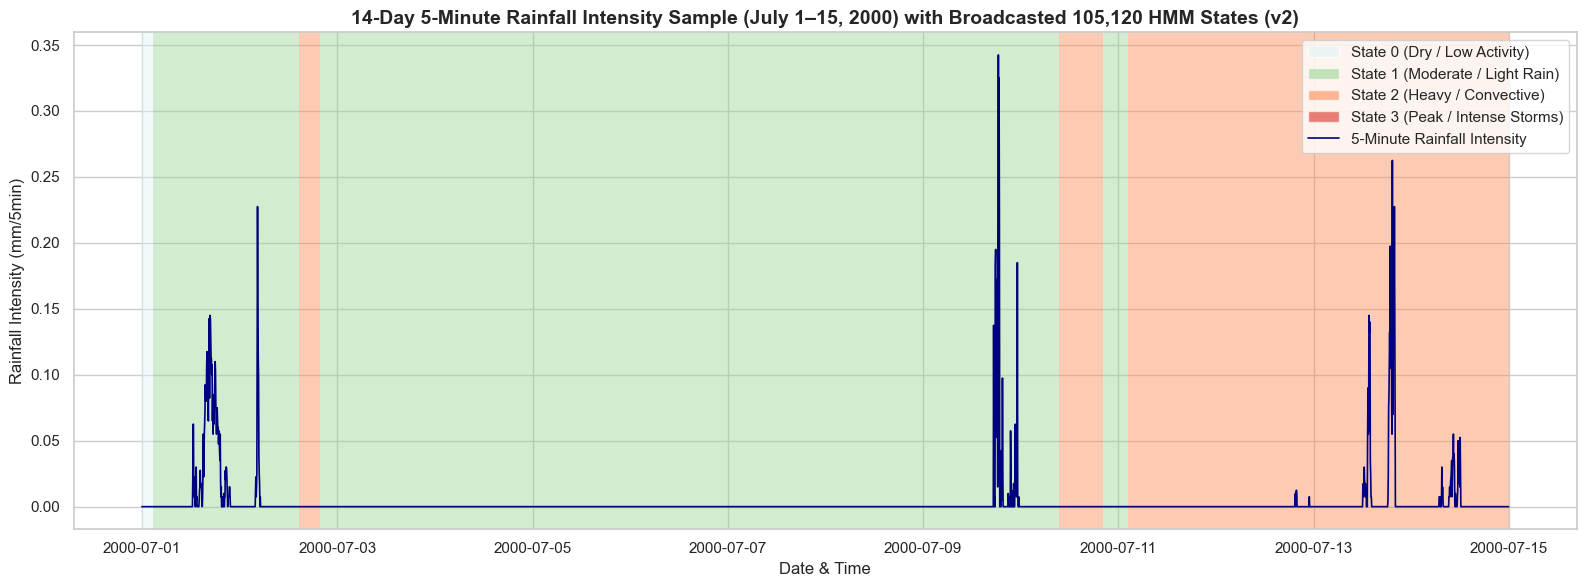

In [12]:
# Sample 14-day window (July 1 to July 15, 2000)
sample_df = df_5min_full[(df_5min_full['datetime'] >= '2000-07-01') & (df_5min_full['datetime'] < '2000-07-15')].copy()

fig, ax = plt.subplots(figsize=(16, 6))

times = sample_df['datetime']
rain = sample_df['rainfall_intensity']
states = sample_df['hmm_state'].values

# Background shading for broadcasted HMM states
current_st = states[0]
start_t = times.iloc[0]

for i in range(1, len(sample_df)):
    if states[i] != current_st or i == len(sample_df) - 1:
        ax.axvspan(start_t, times.iloc[i], color=colors[current_st], alpha=0.45, linewidth=0)
        current_st = states[i]
        start_t = times.iloc[i]

ax.plot(times, rain, color='navy', linewidth=1.2, label='5-Minute Rainfall Intensity')

legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='navy', lw=1.2, label='5-Minute Rainfall Intensity'))

ax.set_title('14-Day 5-Minute Rainfall Intensity Sample (July 1–15, 2000) with Broadcasted 105,120 HMM States (v2)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Rainfall Intensity (mm/5min)')
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [13]:
# Ensure proper datetime parsing
if 'datetime' not in df_5min_full.columns:
    df_5min_full['datetime'] = pd.to_datetime(df_5min_full['date'] + ' ' + df_5min_full['time'], format='%d/%m/%Y %H:%M:%S')
else:
    df_5min_full['datetime'] = pd.to_datetime(df_5min_full['datetime'])
    
# Group by calendar date and count unique HMM states per day
df_5min_full['calendar_date'] = df_5min_full['datetime'].dt.date
daily_unique_states = df_5min_full.groupby('calendar_date')['hmm_state'].nunique()

total_days = len(daily_unique_states)
constant_days = (daily_unique_states == 1).sum()
varying_days = (daily_unique_states > 1).sum()

print("\n" + "=" * 60)
print("INTRA-DAY HMM STATE VARIABILITY REPORT")
print("=" * 60)
print(f"Total Calendar Days      : {total_days:,}")
print(f"Constant State Days      : {constant_days:,} ({constant_days / total_days * 100:.2f}%)")
print(f"Days with >1 HMM State   : {varying_days:,} ({varying_days / total_days * 100:.2f}%)")

if varying_days > 0:
    print("\nSample Days with Intra-day Transitions:")
    sample_dates = daily_unique_states[daily_unique_states > 1].index[:5]
    for dt in sample_dates:
        day_slice = df_5min_full[df_5min_full['calendar_date'] == dt]
        states_in_day = day_slice['hmm_state'].unique().tolist()
        
        # Find the exact timestamp where the state switches
        state_diff = day_slice['hmm_state'].diff() != 0
        switch_times = day_slice.loc[state_diff, 'datetime'].dt.strftime('%H:%M:%S').tolist()
        print(f"  Date {dt}: States = {states_in_day} | State switches at: {switch_times[1:]}")
else:
    print("✓ All days have strictly 1 constant HMM state throughout the 24 hours.")
    
print("=" * 60)



INTRA-DAY HMM STATE VARIABILITY REPORT
Total Calendar Days      : 3,650
Constant State Days      : 3,110 (85.21%)
Days with >1 HMM State   : 540 (14.79%)

Sample Days with Intra-day Transitions:
  Date 2000-01-07: States = [2, 3] | State switches at: ['12:05:00']
  Date 2000-01-09: States = [3, 2] | State switches at: ['18:50:00']
  Date 2000-01-14: States = [2, 1] | State switches at: ['19:25:00']
  Date 2000-01-20: States = [1, 0] | State switches at: ['19:25:00']
  Date 2000-01-29: States = [0, 1] | State switches at: ['16:45:00']


In [14]:
# Extract calendar date
df_5min_full['calendar_date'] = df_5min_full['datetime'].dt.date

# Replace each day's states with the day's mode state
df_5min_full['hmm_state'] = df_5min_full.groupby('calendar_date')['hmm_state'].transform(
    lambda s: s.value_counts().index[0]
).astype(int)

# --- Sanity Check Verification ---
unique_per_day = df_5min_full.groupby('calendar_date')['hmm_state'].nunique()
varying_days = (unique_per_day > 1).sum()

print("=" * 60)
print(f"Days with >1 HMM State after mode assignment: {varying_days} (0.00%)")
print(f"Constant State Days: {(unique_per_day == 1).sum():,} / {len(unique_per_day):,}")
print("State Distribution:\n", df_5min_full['hmm_state'].value_counts().sort_index())
print("=" * 60)


Days with >1 HMM State after mode assignment: 0 (0.00%)
Constant State Days: 3,650 / 3,650
State Distribution:
 hmm_state
0    285984
1    322560
2    301536
3    141120
Name: count, dtype: int64


In [15]:
df_5min_full.head()

,datetime,rainfall_intensity,year,day_of_year,interval_of_day,annual_interval_idx,hmm_state,date,time,calendar_date
0,2000-01-01 00:00:00,0.005,2000,1,0,0,2,01/01/2000,00:00:00,2000-01-01
1,2000-01-01 00:05:00,0.000,2000,1,1,1,2,01/01/2000,00:05:00,2000-01-01
2,2000-01-01 00:10:00,0.000,2000,1,2,2,2,01/01/2000,00:10:00,2000-01-01
3,2000-01-01 00:15:00,0.000,2000,1,3,3,2,01/01/2000,00:15:00,2000-01-01
4,2000-01-01 00:20:00,0.000,2000,1,4,4,2,01/01/2000,00:20:00,2000-01-01


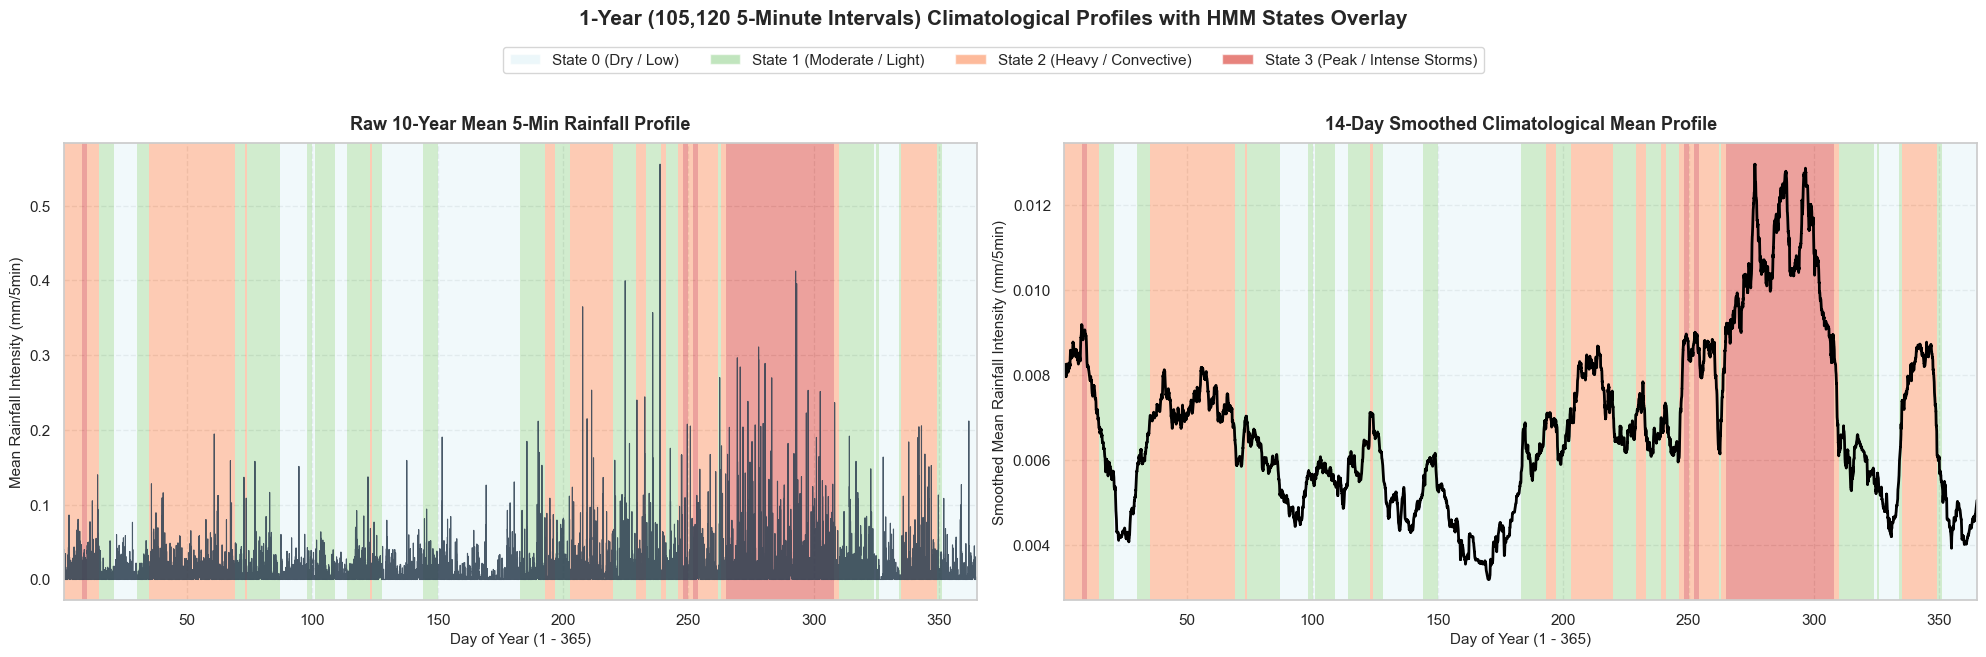

In [16]:
# 1. Aggregate 10-year data to 105,120 interval profile from df_5min_full
df_365 = df_5min_full[df_5min_full['day_of_year'] <= 365].copy()

clim_105120 = df_365.groupby('annual_interval_idx').agg(
    rainfall_intensity=('rainfall_intensity', 'mean'),
    hmm_state=('hmm_state', 'first'),
    day_of_year=('day_of_year', 'first')
).reset_index().set_index('annual_interval_idx')

# 14-day rolling mean (4,032 5-minute steps)
clim_105120['mean_intensity_smooth'] = clim_105120['rainfall_intensity'].rolling(
    window=4032, min_periods=1, center=True
).mean()

# 2. Setup figure & state configurations
state_names = [
    'State 0 (Dry / Low)',
    'State 1 (Moderate / Light)',
    'State 2 (Heavy / Convective)',
    'State 3 (Peak / Intense Storms)'
]
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharex=True)
days = clim_105120.index / 288.0 + 1.0

# 3. Add HMM background state shading to BOTH subplots
for ax in (ax1, ax2):
    current_state = clim_105120['hmm_state'].iloc[0]
    start_idx = 0
    for i in range(1, len(clim_105120)):
        if clim_105120['hmm_state'].iloc[i] != current_state or i == len(clim_105120) - 1:
            ax.axvspan(days[start_idx], days[i], color=colors[current_state], alpha=0.45, linewidth=0)
            current_state = clim_105120['hmm_state'].iloc[i]
            start_idx = i

# 4. Left Plot: Raw 10-Year Mean 5-Minute Profile
ax1.plot(days, clim_105120['rainfall_intensity'], color='#2c3e50', linewidth=0.8, alpha=0.85)
ax1.set_title('Raw 10-Year Mean 5-Min Rainfall Profile', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Day of Year (1 - 365)', fontsize=11)
ax1.set_ylabel('Mean Rainfall Intensity (mm/5min)', fontsize=11)
ax1.set_xlim(1, 365)
ax1.grid(True, linestyle='--', alpha=0.5)

# 5. Right Plot: 14-Day Smoothed Climatological Mean Profile
ax2.plot(days, clim_105120['mean_intensity_smooth'], color='black', linewidth=2.0)
ax2.set_title('14-Day Smoothed Climatological Mean Profile', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Day of Year (1 - 365)', fontsize=11)
ax2.set_ylabel('Smoothed Mean Rainfall Intensity (mm/5min)', fontsize=11)
ax2.set_xlim(1, 365)
ax2.grid(True, linestyle='--', alpha=0.5)

# 6. Shared Legend for HMM States placed above the subplots
legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=4, fontsize=11, frameon=True)

plt.suptitle('1-Year (105,120 5-Minute Intervals) Climatological Profiles with HMM States Overlay', fontsize=15, fontweight='bold', y=1.09)
plt.tight_layout()
plt.show()


HMM STATE RUN DURATION & TRANSIENT SPELLS ANALYSIS
Total Continuous State Spells in Year : 470
Average Spell Duration                : 7.77 days
Median Spell Duration                 : 5.00 days
Spells lasting < 14 days              : 390 / 470 (83.0%)
Spells lasting < 7 days               : 290 / 470 (61.7%)
Spells lasting < 3 days (Bleak Blips) : 170 / 470 (36.2%)

--- Top 15 Shortest State Changes (Duration < 14 Days) ---
 state  start_day  end_day  dur_days  dur_hours                   transition_pattern
     1     1055.0   1056.0       1.0       24.0 State 0 -> State 1 (1.0d) -> State 0
     0     2290.0   2291.0       1.0       24.0 State 1 -> State 0 (1.0d) -> State 1
     0      465.0    466.0       1.0       24.0 State 1 -> State 0 (1.0d) -> State 1
     0     1925.0   1926.0       1.0       24.0 State 1 -> State 0 (1.0d) -> State 1
     0     1054.0   1055.0       1.0       24.0 State 1 -> State 0 (1.0d) -> State 1
     1     2817.0   2818.0       1.0       24.0 State 2 -> St

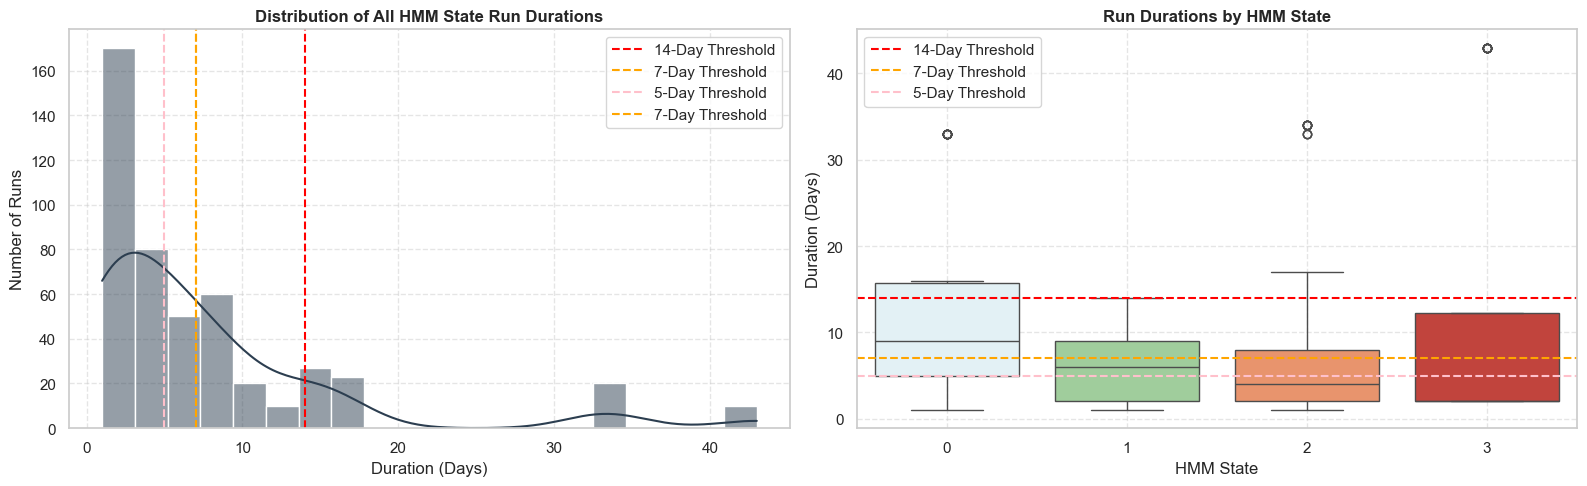

In [17]:
import seaborn as sns

# 1. Extract 105,120 state sequence
states = df_5min_full['hmm_state'].values

# 2. Run-Length Encoding (RLE) to identify continuous state spells
runs = []
current_st = states[0]
start_idx = 0

for i in range(1, len(states)):
    if states[i] != current_st or i == len(states) - 1:
        end_idx = i if states[i] != current_st else i + 1
        dur_steps = end_idx - start_idx
        dur_days = dur_steps / 288.0
        start_day = (start_idx / 288.0) + 1.0
        end_day = (end_idx / 288.0) + 1.0
        
        runs.append({
            'state': int(current_st),
            'start_idx': start_idx,
            'end_idx': end_idx,
            'start_day': round(start_day, 2),
            'end_day': round(end_day, 2),
            'dur_steps': dur_steps,
            'dur_hours': round(dur_steps * 5 / 60.0, 1),
            'dur_days': round(dur_days, 2),
        })
        current_st = states[i]
        start_idx = i

runs_df = pd.DataFrame(runs)

# 3. Identify Previous and Next States for each run
runs_df['prev_state'] = [np.nan] + runs_df['state'].iloc[:-1].tolist()
runs_df['next_state'] = runs_df['state'].iloc[1:].tolist() + [np.nan]

runs_df['transition_pattern'] = runs_df.apply(
    lambda r: f"State {int(r['prev_state']) if pd.notna(r['prev_state']) else 'START'} -> State {int(r['state'])} ({r['dur_days']}d) -> State {int(r['next_state']) if pd.notna(r['next_state']) else 'END'}", 
    axis=1
)

# 4. Summary & Filters for Bleak / Short Runs
short_14d = runs_df[runs_df['dur_days'] < 14.0]
short_7d  = runs_df[runs_df['dur_days'] < 7.0]
short_3d  = runs_df[runs_df['dur_days'] < 3.0]

print("=" * 80)
print("HMM STATE RUN DURATION & TRANSIENT SPELLS ANALYSIS")
print("=" * 80)
print(f"Total Continuous State Spells in Year : {len(runs_df)}")
print(f"Average Spell Duration                : {runs_df['dur_days'].mean():.2f} days")
print(f"Median Spell Duration                 : {runs_df['dur_days'].median():.2f} days")
print(f"Spells lasting < 14 days              : {len(short_14d)} / {len(runs_df)} ({len(short_14d)/len(runs_df)*100:.1f}%)")
print(f"Spells lasting < 7 days               : {len(short_7d)} / {len(runs_df)} ({len(short_7d)/len(runs_df)*100:.1f}%)")
print(f"Spells lasting < 3 days (Bleak Blips) : {len(short_3d)} / {len(runs_df)} ({len(short_3d)/len(runs_df)*100:.1f}%)")
print("=" * 80)

# 5. Top Shortest / Bleakest State Changes (sorted by shortest duration first)
print("\n--- Top 15 Shortest State Changes (Duration < 14 Days) ---")
display_cols = ['state', 'start_day', 'end_day', 'dur_days', 'dur_hours', 'transition_pattern']
print(short_14d.sort_values('dur_days')[display_cols].head(15).to_string(index=False))

# 6. Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

# (a) Histogram of Run Durations
sns.histplot(runs_df['dur_days'], bins=20, kde=True, ax=ax1, color='#2c3e50')
ax1.axvline(14, color='red', linestyle='--', linewidth=1.5, label='14-Day Threshold')
ax1.axvline(7, color='orange', linestyle='--', linewidth=1.5, label='7-Day Threshold')
ax1.axvline(5, color='pink', linestyle='--', linewidth=1.5, label='5-Day Threshold')


ax1.axvline(7, color='orange', linestyle='--', linewidth=1.5, label='7-Day Threshold')
ax1.set_title('Distribution of All HMM State Run Durations', fontsize=12, fontweight='bold')
ax1.set_xlabel('Duration (Days)')
ax1.set_ylabel('Number of Runs')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# (b) Boxplot by State
sns.boxplot(x='state', y='dur_days', data=runs_df, ax=ax2, hue='state', palette=colors, legend=False)
ax2.axhline(14, color='red', linestyle='--', linewidth=1.5, label='14-Day Threshold')
ax2.axhline(7, color='orange', linestyle='--', linewidth=1.5, label='7-Day Threshold')
ax2.axhline(5, color='pink', linestyle='--', linewidth=1.5, label='5-Day Threshold')

ax2.set_title('Run Durations by HMM State', fontsize=12, fontweight='bold')
ax2.set_xlabel('HMM State')
ax2.set_ylabel('Duration (Days)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [18]:
from math import floor

def smooth_hmm_states_min_duration(state_seq, min_days=3, steps_per_day=288):
    """
    Post-processing filter: Merges any state spell lasting < min_days 
    into the surrounding dominant state (eliminates 1-day and 2-day flickers).
    """
    print("Minimum days:", min_days)
    min_steps = int(min_days * steps_per_day)
    s = state_seq.copy()
    
    changed = True
    while changed:
        changed = False
        # 1. Identify all contiguous runs
        runs = []
        cur_st = s[0]
        st_idx = 0
        
        for i in range(1, len(s)):
            if s[i] != cur_st or i == len(s) - 1:
                en_idx = i if s[i] != cur_st else i + 1
                runs.append((cur_st, st_idx, en_idx, en_idx - st_idx))
                cur_st = s[i]
                st_idx = i
        
        # 2. Find and merge the shortest spell below threshold
        for idx, (st_val, start, end, dur) in enumerate(runs):
            if dur < min_steps:
                prev_st = runs[idx - 1][0] if idx > 0 else (runs[idx + 1][0] if idx < len(runs) - 1 else st_val)
                next_st = runs[idx + 1][0] if idx < len(runs) - 1 else prev_st
                
                # If State A -> State B -> State A, revert B back to A
                if prev_st == next_st:
                    s[start:end] = prev_st
                else:
                    # Merge into the longer adjacent neighbor
                    prev_dur = runs[idx - 1][3] if idx > 0 else 0
                    next_dur = runs[idx + 1][3] if idx < len(runs) - 1 else 0
                    s[start:end] = prev_st if prev_dur >= next_dur else next_st
                    
                changed = True
                break
                
    return s

# --- Apply to 105,120 Profile ---
clim_105120['hmm_state_raw'] = clim_105120['hmm_state']
clim_105120['hmm_state'] = smooth_hmm_states_min_duration(
    clim_105120['hmm_state_raw'].values, 
    min_days=floor(runs_df['dur_days'].median())
)

print("=" * 60)
print("HMM STATE POST-PROCESSING COMPLETE")
print("=" * 60)
print("State transitions before smoothing:", np.sum(clim_105120['hmm_state_raw'].values[:-1] != clim_105120['hmm_state_raw'].values[1:]))
print("State transitions after smoothing :", np.sum(clim_105120['hmm_state'].values[:-1] != clim_105120['hmm_state'].values[1:]))
print("=" * 60)


Minimum days: 5
HMM STATE POST-PROCESSING COMPLETE
State transitions before smoothing: 46
State transitions after smoothing : 21


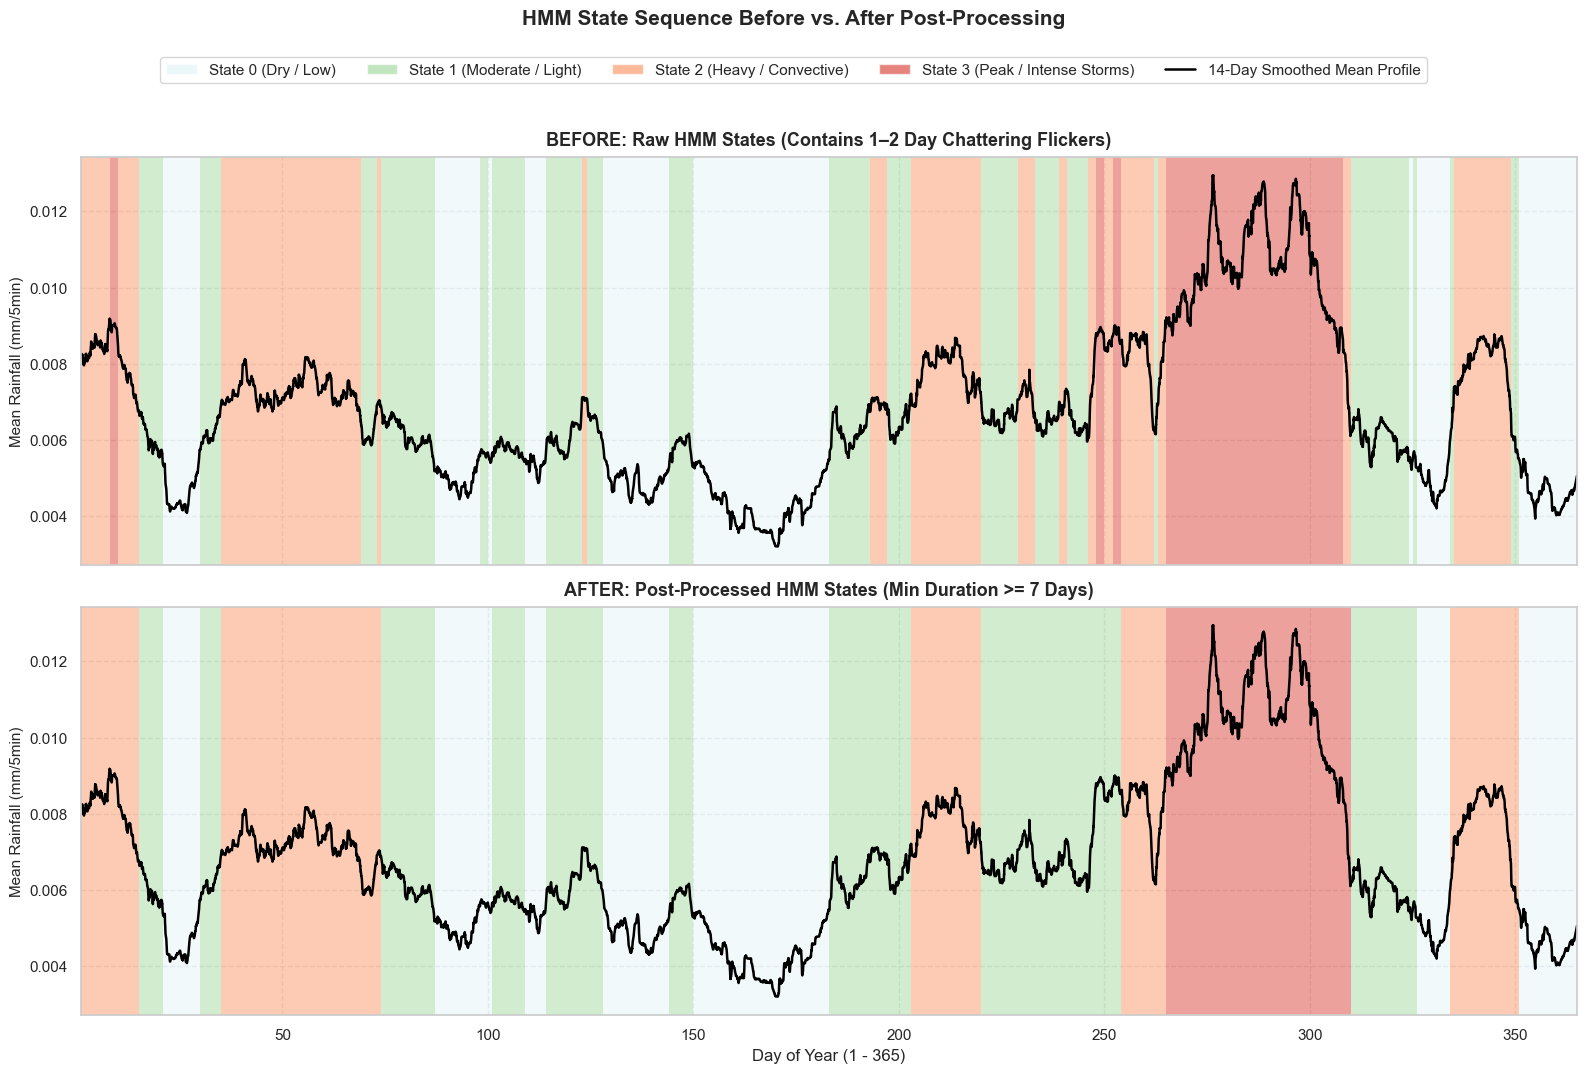

In [19]:
colors = ['#e0f3f8', '#99d594', '#fc8d59', '#d73027']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
days = clim_105120.index / 288.0 + 1.0

# 1. Top Subplot: BEFORE (Raw HMM States with chattering)
cur_st = int(clim_105120['hmm_state_raw'].iloc[0])
st_idx = 0
for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state_raw'].iloc[i] != cur_st or i == len(clim_105120) - 1:
        ax1.axvspan(days[st_idx], days[i], color=colors[cur_st], alpha=0.45, linewidth=0)
        cur_st = int(clim_105120['hmm_state_raw'].iloc[i])
        st_idx = i

ax1.plot(days, clim_105120['mean_intensity_smooth'], color='black', linewidth=1.8)
ax1.set_title('BEFORE: Raw HMM States (Contains 1–2 Day Chattering Flickers)', fontsize=13, fontweight='bold', pad=8)
ax1.set_ylabel('Mean Rainfall (mm/5min)', fontsize=11)
ax1.set_xlim(1, 365)
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Bottom Subplot: AFTER (Post-Processed States >= 7 Days)
cur_st = int(clim_105120['hmm_state'].iloc[0])
st_idx = 0
for i in range(1, len(clim_105120)):
    if clim_105120['hmm_state'].iloc[i] != cur_st or i == len(clim_105120) - 1:
        ax2.axvspan(days[st_idx], days[i], color=colors[cur_st], alpha=0.45, linewidth=0)
        cur_st = int(clim_105120['hmm_state'].iloc[i])
        st_idx = i

ax2.plot(days, clim_105120['mean_intensity_smooth'], color='black', linewidth=1.8)
ax2.set_title('AFTER: Post-Processed HMM States (Min Duration >= 7 Days)', fontsize=13, fontweight='bold', pad=8)
ax2.set_xlabel('Day of Year (1 - 365)', fontsize=12)
ax2.set_ylabel('Mean Rainfall (mm/5min)', fontsize=11)
ax2.set_xlim(1, 365)
ax2.grid(True, linestyle='--', alpha=0.5)

# Shared Legend at the top
legend_elements = [Patch(facecolor=colors[i], alpha=0.6, label=state_names[i]) for i in range(4)]
legend_elements.append(plt.Line2D([0], [0], color='black', lw=1.8, label='14-Day Smoothed Mean Profile'))
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=5, fontsize=11, frameon=True)

plt.suptitle('HMM State Sequence Before vs. After Post-Processing', fontsize=15, fontweight='bold', y=1.07)
plt.tight_layout()
plt.show()


In [21]:
import pickle 

# 1. Map the post-processed HMM states back to the full 10-year 5-minute dataset
interval_state_map = clim_105120['hmm_state'].to_dict()
df_5min_full['hmm_state'] = df_5min_full['annual_interval_idx'].map(interval_state_map)

# Handle leap-day (Day 366) by filling with the last valid state
if df_5min_full['hmm_state'].isna().any():
    last_valid_state = int(clim_105120['hmm_state'].iloc[-1])
    df_5min_full['hmm_state'] = df_5min_full['hmm_state'].fillna(last_valid_state)

df_5min_full['hmm_state'] = df_5min_full['hmm_state'].astype(int)
df_5min_full['date'] = df_5min_full['datetime'].dt.strftime('%d/%m/%Y')
df_5min_full['time'] = df_5min_full['datetime'].dt.strftime('%H:%M:%S')

# 2. Output directory
output_dir = '../data/rainfall/astlingen/hmm_datasets'
if not os.path.exists(output_dir):
    output_dir = 'data/rainfall/astlingen/hmm_datasets'
os.makedirs(output_dir, exist_ok=True)

# 3. Save Full Labeled Dataset
output_csv = os.path.join(output_dir, 'dataset_with_105120_v2_fit_hmm.csv')
df_5min_full[['date', 'time', 'rainfall_intensity', 'day_of_year', 'hmm_state']].to_csv(output_csv, index=False)
print(f"✓ Saved Labeled Dataset: {output_csv} ({len(df_5min_full):,} rows)")

# 4. Save Training Dataset
df_train = pd.DataFrame({
    'datetime': df_5min_full['datetime'],
    'avg_rainfall': df_5min_full['rainfall_intensity'],
    'rainfall_intensity': df_5min_full['rainfall_intensity'],
    'hmm_state': df_5min_full['hmm_state'],
    'day_of_year': df_5min_full['day_of_year'],
})
train_csv = os.path.join(output_dir, 'hmm_105120_v2_train.csv')
df_train.to_csv(train_csv, index=False)
print(f"✓ Saved Training CSV:    {train_csv} ({len(df_train):,} rows)")

# 5. Estimate and Save Block-Level Transition Matrix (24 steps / 2 hours)
def estimate_block_transition_matrix(df, block_size=24, n_states=4, smooth=1e-5):
    states = df['hmm_state'].values
    n_blocks = len(states) // block_size
    block_states = np.zeros(n_blocks, dtype=int)
    for i in range(n_blocks):
        chunk = states[i * block_size : (i + 1) * block_size]
        vals, counts = np.unique(chunk, return_counts=True)
        block_states[i] = vals[np.argmax(counts)]

    C_block = np.zeros((n_states, n_states), dtype=np.float64) + smooth
    for i in range(len(block_states) - 1):
        s1, s2 = block_states[i], block_states[i + 1]
        if 0 <= s1 < n_states and 0 <= s2 < n_states:
            C_block[s1, s2] += 1.0

    P_block = C_block / C_block.sum(axis=1, keepdims=True)
    eigenvalues, eigenvectors = np.linalg.eig(P_block.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    pi_block = np.real(eigenvectors[:, idx])
    pi_block = np.abs(pi_block / np.sum(pi_block))
    unique, counts = np.unique(states, return_counts=True)
    regime_proportions = {int(r): float(c / len(states)) for r, c in zip(unique, counts)}
    n_transitions = sum(1 for i in range(len(block_states) - 1) if block_states[i] != block_states[i + 1])

    return {
        'P_block': P_block, 'P': P_block, 'C_block': C_block,
        'pi_block': pi_block, 'pi': pi_block,
        'regime_proportions': regime_proportions, 'n_states': n_states,
        'block_size': block_size, 'block_sequence': block_states,
        'n_blocks': n_blocks, 'n_transitions': n_transitions,
    }

trans = estimate_block_transition_matrix(df_train, block_size=24, n_states=4)
trans_pkl = os.path.join(output_dir, 'hmm_105120_v2_transition_matrix.pkl')
with open(trans_pkl, 'wb') as f:
    pickle.dump(trans, f)
print(f"✓ Saved Transition Mat:  {trans_pkl}")

print("\n" + "=" * 60)
print("Final State Distribution in v2 Dataset:")
print(df_5min_full['hmm_state'].value_counts().sort_index())
print("\nBlock-Level Transition Matrix (24 steps / 2 hours):\n", np.round(trans['P_block'], 5))
print("\nStationary Distribution:", np.round(trans['pi_block'], 4))
print("=" * 60)


✓ Saved Labeled Dataset: ../data/rainfall/astlingen/hmm_datasets/dataset_with_105120_v2_fit_hmm.csv (1,051,200 rows)
✓ Saved Training CSV:    ../data/rainfall/astlingen/hmm_datasets/hmm_105120_v2_train.csv (1,051,200 rows)
✓ Saved Transition Mat:  ../data/rainfall/astlingen/hmm_datasets/hmm_105120_v2_transition_matrix.pkl

Final State Distribution in v2 Dataset:
hmm_state
0    288864
1    351360
2    281376
3    129600
Name: count, dtype: int64

Block-Level Transition Matrix (24 steps / 2 hours):
 [[9.9427e-01 4.1500e-03 1.5800e-03 0.0000e+00]
 [4.1000e-03 9.9385e-01 2.0500e-03 0.0000e+00]
 [8.5000e-04 2.5600e-03 9.9574e-01 8.5000e-04]
 [0.0000e+00 1.8500e-03 0.0000e+00 9.9815e-01]]

Stationary Distribution: [0.2789 0.3351 0.2643 0.1217]
